# Employee Absentism

In [220]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import scipy.stats
import seaborn as sns

## 1. Create Distribution

In [221]:
avg_absent = 5
possibly_absent = np.arange(0, avg_absent * 5)
probs = scipy.stats.poisson.pmf(possibly_absent, avg_absent)

df = pl.DataFrame({"n_absent": possibly_absent, "prob_absent": probs})
df

n_absent,prob_absent
i64,f64
0,0.006738
1,0.03369
2,0.084224
3,0.140374
4,0.175467
…,…
20,2.6412e-7
21,6.2886e-8
22,1.4292e-8


## 2. Create CD (Cumulated Distribution)

In [222]:
cdf = scipy.stats.poisson.cdf(possibly_absent, avg_absent)
df = df.with_columns(cdf=cdf)
df

n_absent,prob_absent,cdf
i64,f64,f64
0,0.006738,0.006738
1,0.03369,0.040428
2,0.084224,0.124652
3,0.140374,0.265026
4,0.175467,0.440493
…,…,…
20,2.6412e-7,1.0
21,6.2886e-8,1.0
22,1.4292e-8,1.0


## 3. Create Random Numbers

In [223]:
import math

n_numbers = 10000
assigned_numbers = {}
last_num = 0
for idx, (num, prob) in enumerate(zip(possibly_absent, probs)):
    n_num: int = int(math.ceil(prob * n_numbers))
    assigned_numbers[num] = list(range(last_num, last_num + n_num))
    last_num += n_num
print(list(assigned_numbers.values()))
df = df.with_columns(assigned_nums=pl.Series(list(assigned_numbers.values())))
max_value = df.get_column("assigned_nums").list.max().max()
print(max_value)
df

[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67], [68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 2

n_absent,prob_absent,cdf,assigned_nums
i64,f64,f64,list[i64]
0,0.006738,0.006738,"[0, 1, … 67]"
1,0.03369,0.040428,"[68, 69, … 404]"
2,0.084224,0.124652,"[405, 406, … 1247]"
3,0.140374,0.265026,"[1248, 1249, … 2651]"
4,0.175467,0.440493,"[2652, 2653, … 4406]"
…,…,…,…
20,2.6412e-7,1.0,[10011]
21,6.2886e-8,1.0,[10012]
22,1.4292e-8,1.0,[10013]


## Step 4: Generating Randomn Numbers

In [ ]:
rng = np.random.default_rng(42)
random_digits = rng.choice(max_value, size=50, replace=True)
print(random_digits)

[2432 9371 7425 2645 6629 9905 5480 5806  916 8987 3672 5048 4980 5521
 5279  640 8589   78 3483 4891  232 5542 4359 7394 1289 8543  588 9351
 9636 1366 1234 6364 3883  795 3588 5912 7952  925 5080 4280 2751 5849
 4915 2704 7759 4118 8486  319 3267 5468]


## 5. Simulating a Series of Trials

In [225]:
df_expl = df.explode("assigned_nums")
num_df = pl.DataFrame({"assigned_nums": random_digits})

df_sim = df_expl.join(num_df, on="assigned_nums", how="inner")
df_sim.select(pl.col("n_absent").mean())

/var/folders/py/rttdn1tx393dt1bm4s3xzs_h0000gq/T/ipykernel_66192/3195665322.py:1: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  df_expl = df.explode("assigned_nums")


n_absent
f64
4.74


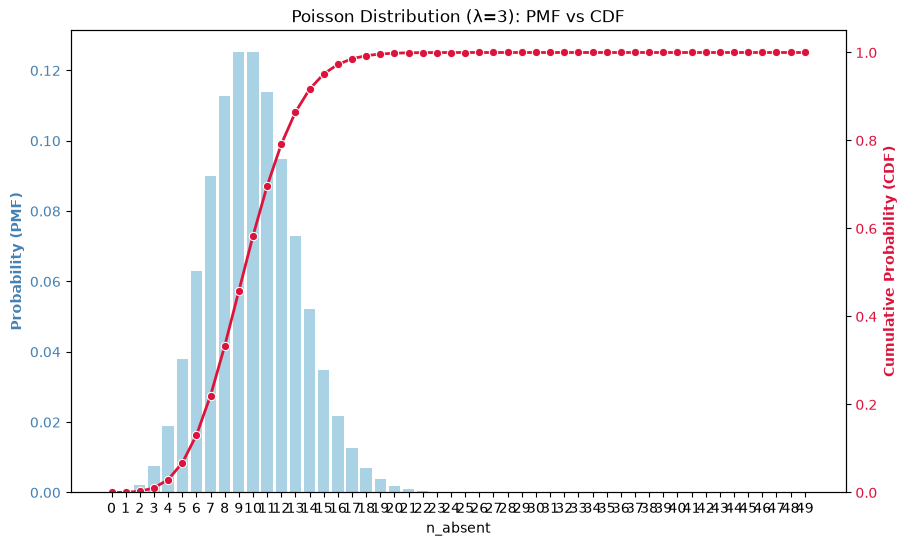

In [226]:
avg_absent = 10
possibly_absent = np.arange(0, avg_absent * 5)
probs = scipy.stats.poisson.pmf(possibly_absent, avg_absent)
cdf = scipy.stats.poisson.cdf(possibly_absent, avg_absent)

df = pl.DataFrame({"n_absent": possibly_absent, "prob_absent": probs, "cdf": cdf})

# 1. Create the figure and the first axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# 2. Plot PMF as a bar chart on the primary y-axis
sns.barplot(data=df, x="n_absent", y="prob_absent", color="skyblue", ax=ax1, alpha=0.8)
ax1.set_ylabel("Probability (PMF)", color="steelblue", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="steelblue")

# 3. Create a secondary y-axis that shares the same x-axis
ax2 = ax1.twinx()

# 4. Plot CDF as a line plot on the secondary y-axis
sns.lineplot(
    data=df, x="n_absent", y="cdf", color="crimson", marker="o", ax=ax2, linewidth=2
)
ax2.set_ylabel("Cumulative Probability (CDF)", color="crimson", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="crimson")
ax2.set_ylim(0, 1.05)  # Force CDF axis to end just above 1.0

plt.title("Poisson Distribution (λ=3): PMF vs CDF")
plt.show()

# BTC

In [227]:
import polars as pl

path = "/Users/zipp/Desktop/programming/ml-training/data/bitcoin_dataset.csv"
lf = pl.scan_csv(path, infer_schema_length=2908)
lf = lf.sort(by="Date", descending=False).select("btc_market_price")
mean = lf.select(pl.col("btc_market_price").mean()).collect().item()
std = lf.select(pl.col("btc_market_price").std()).collect().item()
print(mean, std)

839.1042175232348 2304.9724966808326


In [228]:
import numpy as np

seed = 42
rng = np.random.default_rng(seed)
size = 100
stock_prices = rng.normal(mean, std, size)
pl.DataFrame({"stock_prices": stock_prices})

stock_prices
f64
1541.468706
-1558.030544
2568.873584
3007.08002
-3657.978232
…
-2496.450231
-2209.68201
-1459.522293


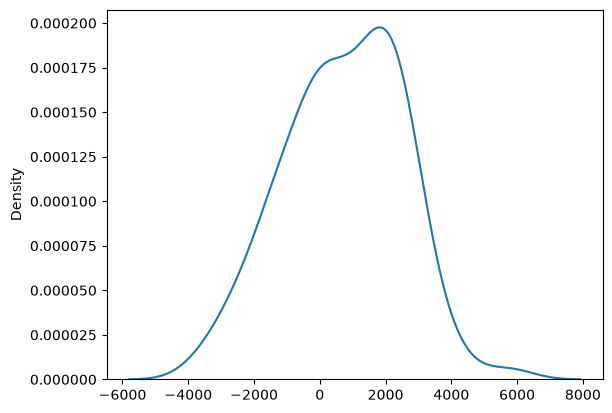

In [229]:
import seaborn as sns

plot = sns.kdeplot(stock_prices)

<Axes: >

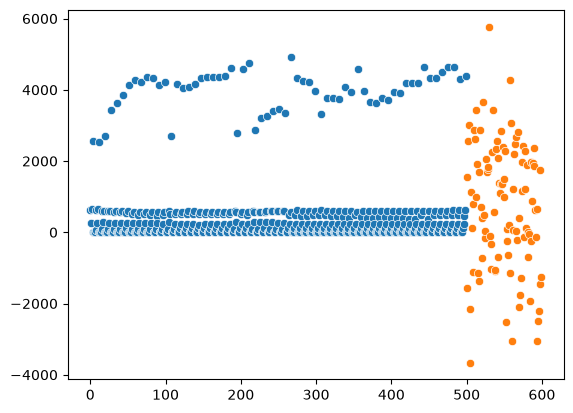

In [230]:
sns.scatterplot(lf.tail(500).collect().get_column("btc_market_price"))
sns.scatterplot(y=stock_prices, x=range(500, 500 + len(stock_prices)))